In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from alpha.analysist import datastore

In [3]:
ds = datastore.DataStore(live=False)

In [17]:
td = ds.indicators(symbol="005930", label="OFI_KF", start="2026-09-02", end="2026-09-02")

In [18]:
td.split_by_gap(max_gap="1min").segments[1].base.times[[0,-1]]

DatetimeIndex(['2026-09-02 10:38:14', '2026-09-02 11:39:47'], dtype='datetime64[ns]', name='t', freq=None)

In [19]:
td.tslice(start='2026-09-02 10:38:20', end='2026-09-02 11:32:47').where(lambda df: (df["line"]=="level") & (df['value']>=2)).base.times

DatetimeIndex([], dtype='datetime64[ns]', name='t', freq=None)

In [20]:
kalman = td.tslice(start='2026-09-02 10:59:34', end='2026-09-02 11:29:34')

In [21]:
price = ds.ticks(symbol="005930", start="2026-09-02", end="2026-09-02")

In [22]:
price = price.calc('mid', 'bid', '+', 'ask').calc('mid', 'mid', '/', 2)

In [23]:
mid_price = price.tslice(start='2026-09-02 10:59:34', end='2026-09-02 11:29:34').relative('mid', replace=True)

In [24]:
kalman.series()

['indicator@OFI_KF.value[005930|level]',
 'indicator@OFI_KF.value[005930|lead]',
 'indicator@OFI_KF.value[005930|nis]',
 'indicator@OFI_KF.value[005930|obs_var]',
 'indicator@OFI_KF.value[005930|slope]']

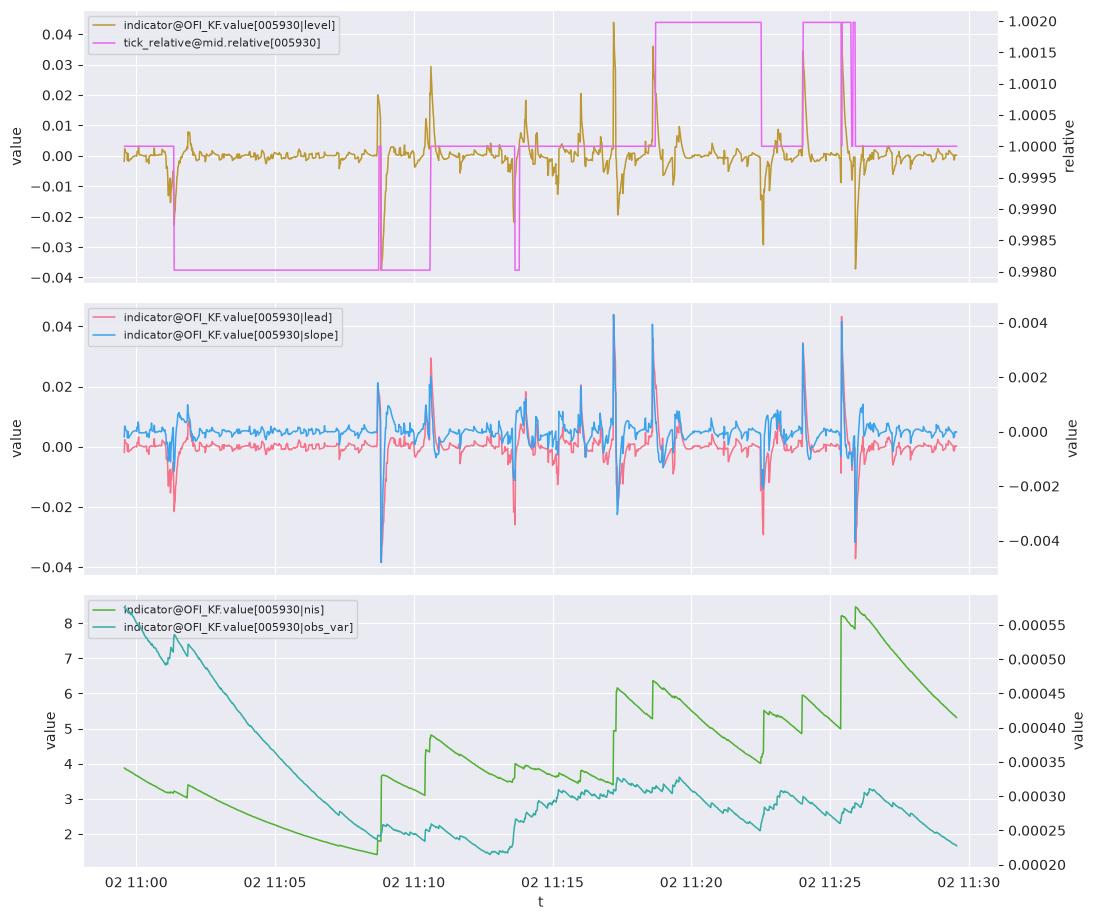

(<Figure size 1100x930 with 6 Axes>,
 [<Axes: ylabel='value'>,
  <Axes: ylabel='value'>,
  <Axes: xlabel='t', ylabel='value'>])

In [25]:
kalman.add(mid_price).plot(layout=[
    (['indicator@OFI_KF.value[005930|level]'],['tick_relative@mid.relative[005930]']),
    (['indicator@OFI_KF.value[005930|lead]'],['indicator@OFI_KF.value[005930|slope]']),
    (['indicator@OFI_KF.value[005930|nis]'],['indicator@OFI_KF.value[005930|obs_var]'])
])

In [26]:
bar_sam = ds.bars(symbol='005930', start="2026-09-02", end="2026-09-02", seconds=60)
bar_sh = ds.bars(symbol='000660', start="2026-09-02", end="2026-09-02", seconds=60)

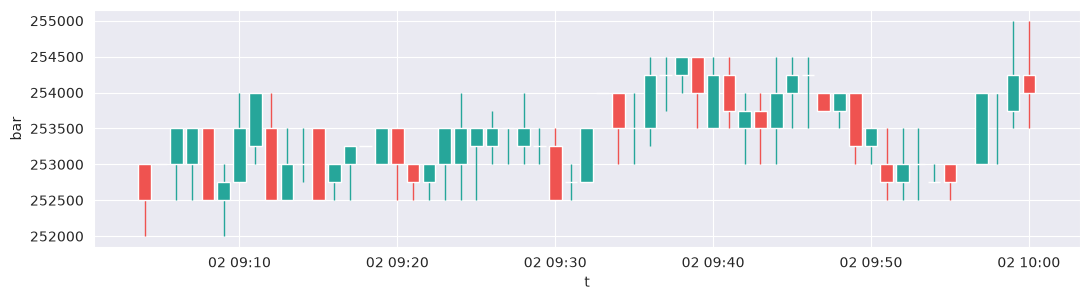

(<Figure size 1100x310 with 1 Axes>, [<Axes: xlabel='t', ylabel='bar'>])

In [27]:
bar_sam.tslice(start="2026-09-02 09:00", end="2026-09-02 10:00").plot(kind={'bar@60':'candle'})

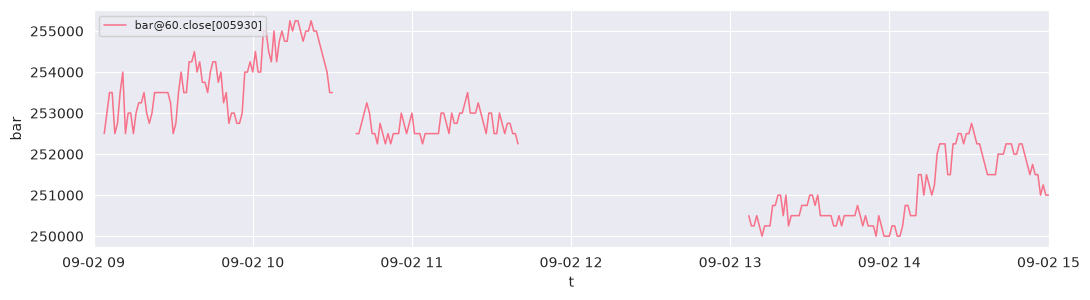

(<Figure size 1100x310 with 1 Axes>, [<Axes: xlabel='t', ylabel='bar'>])

In [28]:
bar_sam.time_frame(start="2026-09-02 09:00", end="2026-09-02 15:00", mode='min').plot(columns=["close"])